In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip3 install ipython-autotime
!pip3 install detoxify

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 1.6 MB 38.6 MB/s 
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 5.5 MB 47.5 MB/s 
     |████████████████████████████████| 1.3 MB 62.9 MB/s 
     |████████████████████████████████| 7.6 MB 44.9 MB/s 
     |████████████████████████████████| 182 kB 73.7 MB/s 


In [3]:
%load_ext autotime
import pandas as pd
import numpy as np
# import pickle5 as pickle
import re
from tqdm.notebook import tqdm
tqdm.pandas()
import os
import re
import pickle as pkl
from detoxify import Detoxify

punctuations = """!"$%()*+,*/:»«";“<=>?[\]^`”|{.}~"""
def clean_text_local(row):
    row=re.sub('\x0c',' ',row)
    row=re.sub('\u200c',' ',row)
    # row=re.sub('\n\n',' . ',row)
    # row=re.sub('\\n',' ',row)

    row=re.sub('\\\\n',' ',row)
    row=re.sub('\n',' ',row)
    
    row=re.sub("-?NEWLINE_TOKEN", " ",row)
    row=re.sub("TAB_TOKEN", " ",row)
    row=re.sub("Alternate option=", "",row)
    row=re.sub('RT',' ',row)
    row = row.lower()
    
    row=re.sub("@[A-Za-z0-9_]+","",row)
    row=re.sub("http\S+|www.\S+","",row)

    row = re.sub(r'<.*?>', ' ', row)
    row = re.sub('\w*\d\w*','',row)
    row=re.sub("&amp","&",row)
#     row=re.sub("\d","",row)
#     row=re.sub(r"\b\d+\b|\b(?![i])[a-z]\b","",row) # removes every isolated number or char except i
    # row = ' '.join([lemmatizer.lemmatize(w) for w in nltk.word_tokenize(row)])
    row=re.sub('-',' ',row)
    # no_punct = ""
    # for char in row:
    #     if char not in punctuations:
    #         no_punct = no_punct + char
    # no_punct = no_punct.strip()
    row = re.sub('\s+',' ',row)
    return row

time: 9.31 s (started: 2022-12-01 17:11:50 +00:00)


In [ ]:
# !unzip "/content/drive/MyDrive/Kialo/kialo_debates.zip" -d "/content/drive/MyDrive/Kialo/"

In [9]:
dataset_path = '/content/drive/MyDrive/Kialo/serializedGraphs/'
files = os.listdir(dataset_path)
dataset_samples = []
labels = []
text_df=pd.DataFrame()

for file in tqdm(files):
    data = pkl.load(open(dataset_path + file, 'rb'))
    print(f'{file} >>> ',end='')
    for node_x_key in data.node:
      node_x = data.node[node_x_key]
      node_x.update({'file': file})
      text_df = text_df.append(node_x,ignore_index=True)

  0%|          | 0/1560 [00:00<?, ?it/s]

24631.pkl >>> 31941.pkl >>> 18740.pkl >>> 23902.pkl >>> 10343.pkl >>> 2469.pkl >>> 23340.pkl >>> 23831.pkl >>> 31832.pkl >>> 10341.pkl >>> 29929.pkl >>> 16026.pkl >>> 17763.pkl >>> 2408.pkl >>> 16218.pkl >>> 29923.pkl >>> 2710.pkl >>> 17822.pkl >>> 27032.pkl >>> 14447.pkl >>> 12278.pkl >>> 30362.pkl >>> 17768.pkl >>> 32290.pkl >>> 31828.pkl >>> 32864.pkl >>> 17976.pkl >>> 15489.pkl >>> 5496.pkl >>> 15628.pkl >>> 16962.pkl >>> 26453.pkl >>> 16755.pkl >>> 16598.pkl >>> 16201.pkl >>> 23728.pkl >>> 24439.pkl >>> 7768.pkl >>> 1955.pkl >>> 14232.pkl >>> 1922.pkl >>> 7776.pkl >>> 7487.pkl >>> 921.pkl >>> 29497.pkl >>> 26461.pkl >>> 15491.pkl >>> 9576.pkl >>> 14940.pkl >>> 16680.pkl >>> 16566.pkl >>> 18191.pkl >>> 13876.pkl >>> 4401.pkl >>> 6086.pkl >>> 23139.pkl >>> 28280.pkl >>> 15121.pkl >>> 16974.pkl >>> 19648.pkl >>> 12788.pkl >>> 15943.pkl >>> 31028.pkl >>> 29944.pkl >>> 27936.pkl >>> 30959.pkl >>> 25506.pkl >>> 13225.pkl >>> 5909.pkl >>> 1108.pkl >>> 26678.pkl >>> 7572.pkl >>> 23298.pkl

In [14]:
text_df.to_csv('/content/drive/MyDrive/Kialo/all_text.csv')

time: 3.64 s (started: 2022-12-01 18:30:06 +00:00)


In [4]:
text_df=pd.read_csv('/content/drive/MyDrive/Kialo/all_text.csv')

time: 3.64 s (started: 2022-12-01 17:12:30 +00:00)


In [10]:
model=Detoxify('original',device='cuda')

Downloading: "https://github.com/unitaryai/detoxify/releases/download/v0.1-alpha/toxic_original-c1212f89.ckpt" to /root/.cache/torch/hub/checkpoints/toxic_original-c1212f89.ckpt


  0%|          | 0.00/418M [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/570 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/232k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

time: 2min 1s (started: 2022-12-01 17:14:41 +00:00)


In [12]:
text_df['Toxic_BERT']=text_df['text'].progress_apply(lambda x: model.predict(str(x))['toxicity'])

  0%|          | 0/329013 [00:00<?, ?it/s]

time: 1h 12min 15s (started: 2022-12-01 17:17:16 +00:00)


In [18]:
text_df.drop_duplicates(subset='text', inplace=True)

time: 135 ms (started: 2022-12-01 18:39:05 +00:00)


In [20]:
text_df

,Unnamed: 0,edited,votes,created,text,author,relation,file,Toxic_BERT
0,0,1.544792e+12,"[0, 0, 0, 0, 0]",1.544792e+12,Retention elections don't especially politiciz...,0dd5353c-3947-4069-9e12-c051be197740,1.0,24631.pkl,0.000718
1,1,1.544792e+12,"[0, 0, 0, 0, 0]",1.544792e+12,Supreme Court Justices already hold largely to...,0dd5353c-3947-4069-9e12-c051be197740,1.0,24631.pkl,0.000573
2,2,1.544792e+12,"[0, 0, 0, 0, 0]",1.544792e+12,It's unlikely this sort of constitutional amen...,0dd5353c-3947-4069-9e12-c051be197740,-1.0,24631.pkl,0.000584
3,3,1.544792e+12,"[0, 0, 0, 0, 0]",1.544792e+12,This would be a massive constitutional shift.,0dd5353c-3947-4069-9e12-c051be197740,-1.0,24631.pkl,0.000712
4,4,1.544791e+12,"[0, 0, 0, 0, 0]",1.544791e+12,Americans should be able to vote on whether or...,0dd5353c-3947-4069-9e12-c051be197740,0.0,24631.pkl,0.000976
...,...,...,...,...,...,...,...,...,...
329008,329008,1.569865e+12,"[0, 0, 0, 0, 0]",1.569865e+12,This is an appropriate consequence for their f...,0af77b22-4423-4481-bb50-a0a70d7c57c4,-1.0,30562.pkl,0.000969
329009,329009,1.569865e+12,"[0, 0, 0, 0, 0]",1.569865e+12,Shutting down the internet does not mean destr...,0af77b22-4423-4481-bb50-a0a70d7c57c4,-1.0,30562.pkl,0.018097
329010,329010,1.569678e+12,"[0, 0, 0, 0, 0]",1.569678e+12,People can find about this through [whistleblo...,bcd8245e-38da-4079-840e-695f01d30806,1.0,30562.pkl,0.000552
329011,329011,1.569678e+12,"[0, 0, 0, 0, 0]",1.569678e+12,Governments can easily deny this since the inf...,bcd8245e-38da-4079-840e-695f01d30806,-1.0,30562.pkl,0.000638


time: 18.3 ms (started: 2022-12-01 18:39:20 +00:00)


In [21]:
toxic_text_df=text_df[text_df['Toxic_BERT']>0.5]

time: 4.81 ms (started: 2022-12-01 18:49:36 +00:00)


In [24]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import imageio

# reddit_mask = imageio.imread(my_dir+'Charts/Reddit Mask.png')

time: 64.2 ms (started: 2022-12-01 18:53:06 +00:00)


In [26]:
all_text = " ".join(clean_text_local(text_i) for text_i in toxic_text_df['text'])

time: 53.3 ms (started: 2022-12-01 18:54:08 +00:00)


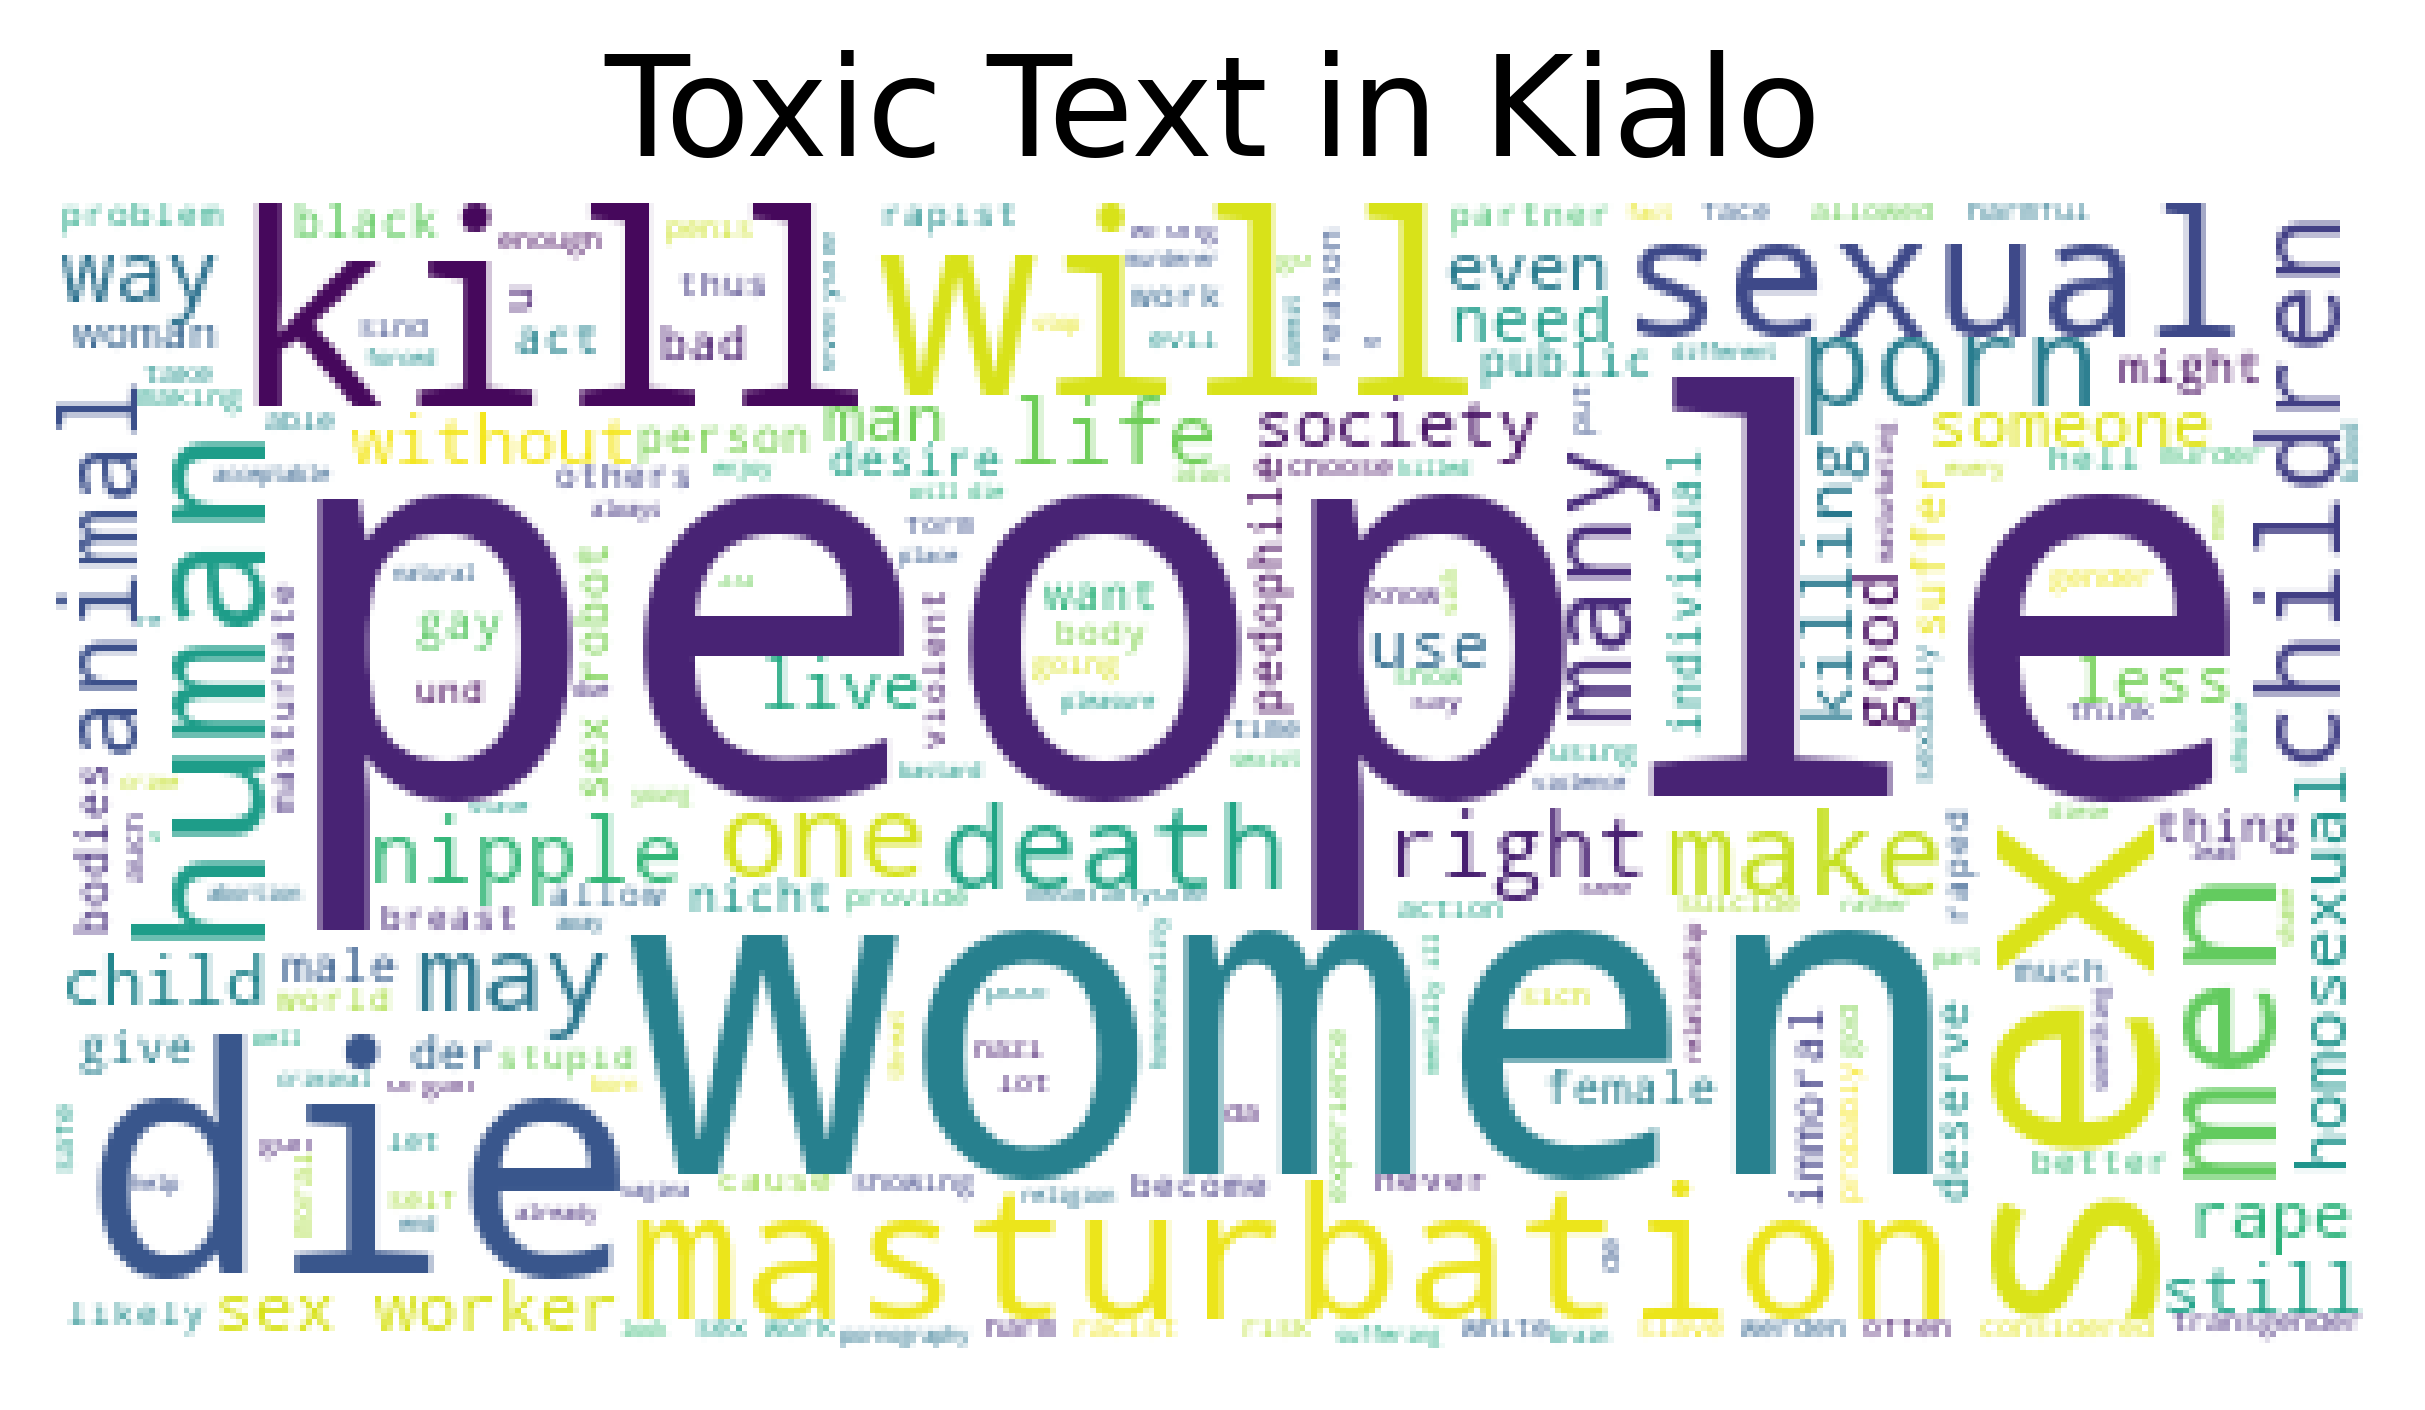

time: 1.93 s (started: 2022-12-01 19:09:39 +00:00)


In [28]:
kialo_wordcloud = WordCloud(background_color="white",random_state=1)
my_kialo_wordcloud = kialo_wordcloud.generate(all_text) #.generate_from_frequencies(reddit_tags)


plt.figure(dpi=500)
plt.title('Toxic Text in Kialo',fontsize=20)
plt.imshow(my_kialo_wordcloud)
plt.axis("off")
plt.savefig('/content/drive/MyDrive/Kialo/toxic_wordcloud.png', format="png", dpi=300)
plt.show()